# Notebook 1: Dane i przetwarzanie wstępne

**Autor:** Michał Bogdański

**Opis:** Projekt realizuje sentymentu recenzji steam po angielsku. Porównujemy podejście klasyczne (TF-IDF + SVM) z podejściem opartym na Transformerach (HerBERT).

**Źródło danych:** Zbiór `Steam Reviews` z kaggle.com – podział na oceny pozytywne i negatywne.

W tym notebooku:
1. Ładujemy dane
2. Przeprowadzamy eksploracyjną analizę danych (EDA)
3. Wykonujemy przetwarzanie wstępne tekstu
4. Dzielimy dane na zbiory treningowy, walidacyjny i testowy

## 1. Instalacja i import bibliotek

In [22]:
!pip install datasets pandas matplotlib seaborn scikit-learn wordcloud spacy -q
!python -m spacy download en_core_web_sm -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import spacy
import unicodedata
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Ustawienia wyświetlania
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

C:\Users\HardPC\PycharmProjects\AnalizaSentymentuSteam\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Załadowanie danych

Korzystamy ze zbioru `Steam Reviews` dostępnego na kaggle.com. Zbiór zawiera recenzje gier ze steam (pozytywne/negatywne)

In [3]:
df = pd.read_csv("final_fantasy_XIII.csv")
df = df.dropna()
print(f"Liczba rekordów: {len(df)}")
print(f"Kolumny: {list(df.columns)}")
df.head()

Liczba rekordów: 3899
Kolumny: ['review_text', 'review_score']


,review_text,review_score
0,"This game has a tremendous polarizing effect on gamers. Either you love it, or you hate it. Hence I'm not surprised to see such mixed reviews. (Of course, the poor port is adding fuel to the negat...",1
1,"From what I have gathered, this game is somewhat controversial. I have 3 playthroughs now, looking forward to a 4th, and I would like to bring up a few points and offer my opinions, that potential...",1
2,"It's really hard to talk about this game. I've finally beaten Final Fantasy XIII and the first thing that comes to mind is, it really is a unique experience. So, is it good? Well, I can't say I li...",-1
3,"ok, now i finally beat this game, time for a review english is not my main language, so bear with it.",1
4,This review is spoiler-free. First things first: let me list some important points which may very well influence you taking my recommendation seriously. I am new to Final Fantasy series. I h...,1


In [4]:
print("Podgląd kolumn i typów:")
print(df.dtypes)

Podgląd kolumn i typów:
review_text       str
review_score    int64
dtype: object


In [5]:
# review_score, 1 - pozytywne, -1 - negatywne
TEXT_COL = "review_text"
RATING_COL = "review_score"

print(f"\nRozkład sentymentu:")
print(df[RATING_COL].value_counts())


Rozkład sentymentu:
review_score
 1    2805
-1    1094
Name: count, dtype: int64


## 3. Eksploracyjna analiza danych (EDA)

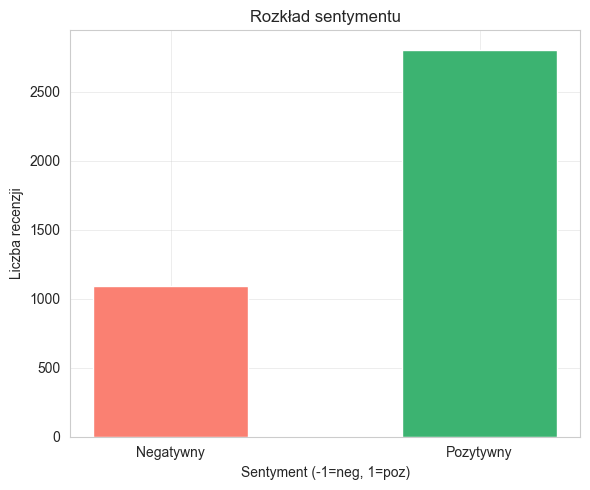

In [6]:
# Rozkład recenzji
counts = df[RATING_COL].value_counts().sort_index()
labels = ["Negatywny", "Pozytywny"]
colors = ["salmon", "mediumseagreen"]

plt.figure(figsize=(6, 5))
plt.bar(labels, counts, color=colors, width=0.5)

plt.title("Rozkład sentymentu")
plt.xlabel("Sentyment (-1=neg, 1=poz)")
plt.ylabel("Liczba recenzji")

plt.tight_layout()
plt.show()

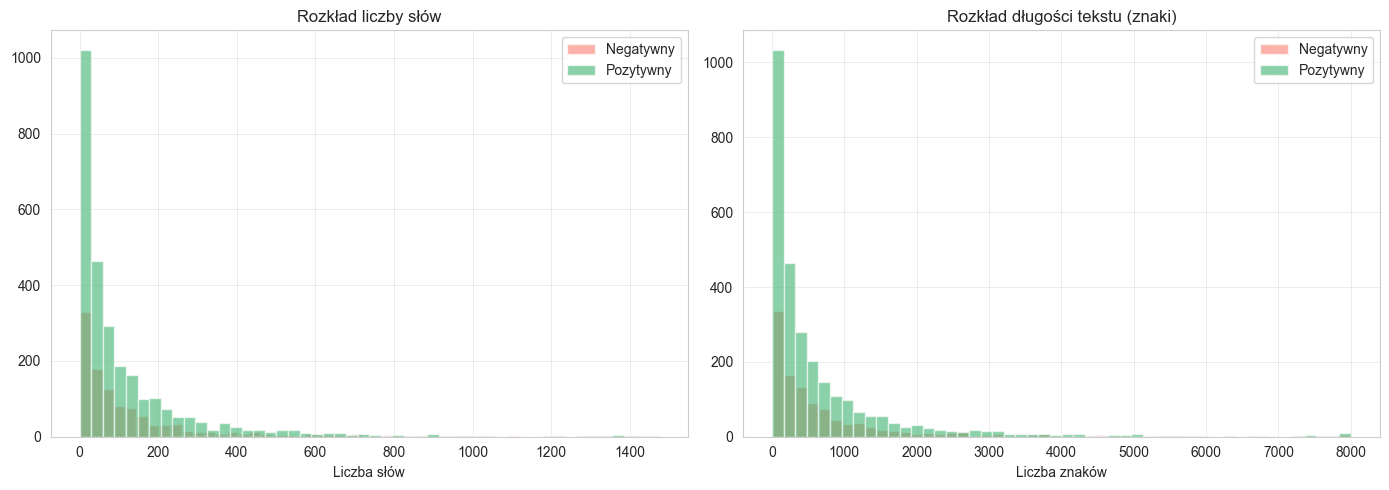

Statystyki długości recenzji (słowa):
               count        mean         std  min   25%   50%    75%     max
review_score                                                                
-1            1094.0  138.809872  200.824003  1.0  25.0  67.5  162.0  1435.0
 1            2805.0  121.104100  185.987776  0.0  17.0  53.0  144.0  1473.0


In [7]:
# Długość recenzji
df["text_length"] = df[TEXT_COL].astype(str).apply(len)
df["word_count"] = df[TEXT_COL].astype(str).apply(
    lambda x: len(x.split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sent, color, label in [(-1, "salmon", "Negatywny"), (1, "mediumseagreen", "Pozytywny")]:
    subset = df[df[RATING_COL] == sent]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title("Rozkład liczby słów")
axes[0].set_xlabel("Liczba słów")
axes[0].legend()

axes[1].set_title("Rozkład długości tekstu (znaki)")
axes[1].set_xlabel("Liczba znaków")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statystyki długości recenzji (słowa):")
print(df.groupby(RATING_COL)["word_count"].describe())

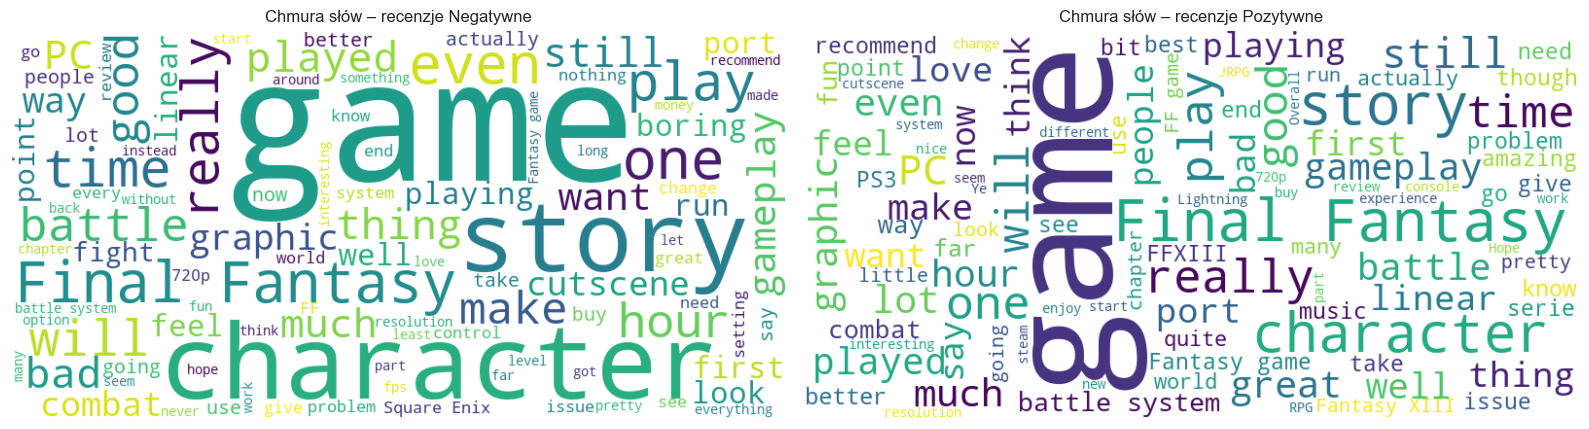

In [8]:
# Najczęstsze słowa dla każdego sentymentu
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, title) in enumerate([(-1, "Negatywne"), (1, "Pozytywne")]):
    texts = " ".join(df[df[RATING_COL] == sent][TEXT_COL].astype(str))
    wc = WordCloud(
        width=800, height=400, background_color="white", max_words=100
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów – recenzje {title}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4. Przetwarzanie wstępne tekstu

In [9]:
# Ładowanie modelu spaCy dla języka angielskiego
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess_text(text):
    """Nowoczesny pipeline: normalizacja → spaCy (tokenizacja + POS + lematyzacja) → filtrowanie."""

    # 1. Minimalna normalizacja (spaCy radzi sobie z resztą)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Przetwarzanie przez spaCy (tokenizacja + POS + lematyzacja w jednym kroku)
    doc = nlp(text)

    # 3. Filtrowanie: bez stop words, bez interpunkcji, bez spacji
    tokens = []
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space:
            continue
        tokens.append(token.lemma_.lower())

    return " ".join(tokens)


# Przykład działania
sample_text = df[TEXT_COL].iloc[0]
print(f"Oryginał: {sample_text[:200]}")
print(f"\nPo przetworzeniu: {preprocess_text(sample_text)[:200]}")

Oryginał: This game has a tremendous polarizing effect on gamers. Either you love it, or you hate it. Hence I'm not surprised to see such mixed reviews. (Of course, the poor port is adding fuel to the negative 

Po przetworzeniu: game tremendous polarizing effect gamer love hate surprised mixed review course poor port add fuel negative flame address view later come play final fantasy game entry point franchise play jrpg pc ps3


In [10]:
# Przetwarzanie wstępne dla podejścia klasycznego
# (Transformer będzie korzystał z surowego tekstu)
print("Przetwarzanie tekstu... (może potrwać kilka minut)")
df["text_clean"] = df[TEXT_COL].astype(str).apply(preprocess_text)

# Usunięcie pustych rekordów po przetworzeniu
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Rekordów po przetworzeniu: {len(df)}")

Przetwarzanie tekstu... (może potrwać kilka minut)
Rekordów po przetworzeniu: 3893


In [12]:
# Ograniczenie do rozsądnej liczby przykładów (Google Colab ma limity pamięci)
MAX_SAMPLES = 5000

if len(df) > MAX_SAMPLES:
    df_sample = df.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Losowo wybrano {MAX_SAMPLES} próbek z {len(df)}")
else:
    df_sample = df.copy()
    print(f"Używamy pełnego zbioru: {len(df_sample)} próbek")

# Podział: 70% trening, 15% walidacja, 15% test
train_df, temp_df = train_test_split(
    df_sample, test_size=0.3, random_state=42, stratify=df_sample[RATING_COL]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df[RATING_COL]
)

print(f"\nRozmiary zbiorów:")
print(f"  Treningowy: {len(train_df)}")
print(f"  Walidacyjny: {len(val_df)}")
print(f"  Testowy: {len(test_df)}")

print(f"\nRozkład sentymentu w zbiorze treningowym:")
print(train_df[RATING_COL].value_counts(normalize=True))

Używamy pełnego zbioru: 3893 próbek

Rozmiary zbiorów:
  Treningowy: 2725
  Walidacyjny: 584
  Testowy: 584

Rozkład sentymentu w zbiorze treningowym:
review_score
 1    0.718899
-1    0.281101
Name: proportion, dtype: float64


In [1]:
# Zapis przetworzonych danych do plików CSV
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Dane zapisane do plików: train.csv, val.csv, test.csv")
print("\nKolumny w pliku:")
print(f"  '{TEXT_COL}' - oryginalny tekst (dla Transformerów)")
print(f"  'text_clean' - przetworzony tekst (dla podejścia klasycznego)")
print(f"  '{RATING_COL}' - etykieta (-1=negatywny, 1=pozytywny)")

NameError: name 'train_df' is not defined